# **<p align="center"> Project Intro </p>**

## <ins> Description </ins>
### The goal of this project is to go over the most recent Wankowicz paper data, try to reproduce their results, and understand whether they can be trusted.

[Paper url](https://www.biorxiv.org/content/10.64898/2026.01.19.699807v1)

<p align="center">  

<img src="../../../images/wankowics/fig1a.png" width="30%"  >
<br>
slope = 0.85, R2 = 0.59
</p>

<details open>
<summary> <font size="6"> <ins> Key Tasks</ins> </font> </summary>

- Extract the data

</details>

</br>



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
rootdir = Path("../../..").resolve()
rootdir.__str__()
sys.path.insert(0, rootdir.__str__() )

---

## Bullet point 1

- ### Subpoint 1.1

In [2]:
file_path = rootdir.joinpath("data/entropy/wankowics/media-2.csv")
df = pd.read_csv(file_path)
display( df.head())

,PDB,Protein,Protein_Entropy,dCP,avg_dsasa,avg_dapolar,avg_dpolar,Num_Water_Corrected,Num_Water_Count,TdS,dH,dG,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,x4034,Mac1,-4.6075,-0.130274,-0.629385,-0.626116,-0.651253,-0.208117,-0.244578,-5.821826,-1.67,-7.491826,NaN,NaN,NaN,NaN,NaN,NaN
1,x3458,Mac1,-4.5725,0.425297,0.085791,-0.344632,0.745984,-0.358274,-0.422892,-4.737089,-1.42,-6.157089,NaN,NaN,NaN,NaN,NaN,NaN
2,7HHZ,Mac1,-3.3375,0.156951,-0.639280,-1.196156,-0.342333,-0.132847,-0.096386,-4.973552,-1.20,-6.173552,NaN,NaN,NaN,NaN,NaN,NaN
3,x3450,Mac1,-2.7950,0.130044,-0.314863,-0.630717,-0.075427,-0.168675,-0.205846,-5.450750,-0.96,-6.410750,NaN,NaN,NaN,NaN,NaN,NaN
4,7HFK,Mac1,-2.1900,-0.036309,-0.452656,-0.617941,-0.437720,-0.313570,-0.277108,-0.530000,-0.53,-4.350000,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
names, counts= df["Protein"].value_counts().index.tolist(), df["Protein"].value_counts().tolist()
prot_counts = dict( sorted( zip(names, counts), key = lambda item: int(item[1]) , reverse = True))
print(prot_counts)

{'HCAII': 19, 'Mac1': 14, 'Thermolysin': 12, 'TGT': 9, 'BRD4': 6, 'TTR': 4, 'MUP-I': 2, 'FPS': 2, 'Galectin': 2, 'CDK2': 1, 'Trypsin': 1}


In [4]:
from scipy.stats import pearsonr, linregress
from sklearn.linear_model import LinearRegression

# corr, p_val = pearsonr(df["TdS"], df["Protein_Entropy"])
# print(corr, p_val)
# slope, intercept, r_value, p_value, std_err = linregress(df["TdS"], df["Protein_Entropy"])
# r_squared = r_value**2
# print(f"Slope: {slope}")
# print(f"R-squared: {r_squared}")


def plot_corr(df ): 
    sign_fig = 3
    corr, p_val = pearsonr( df["TdS"], df["Protein_Entropy"])
    print("Pearson Correlation")
    print(f"\tCorr: {round( corr, sign_fig )}")
    print(f"\tp_val: {round(p_val, sign_fig)}")

    slope, intercept, r_value, p_value, std_err = linregress( df["TdS"], df["Protein_Entropy"])
    r_squared = r_value**2
    print("Linear Regression")
    print(f"\tSlope: {round(slope, sign_fig)}")
    print(f"\tR-squared: {round(r_squared, sign_fig)}")

    labels = set( df["Protein"].to_list() )
    min, max = np.min( [np.min( df["TdS"]), np.min(df["Protein_Entropy"])]  ), np.max( [np.max( df["TdS"]), np.max(df["Protein_Entropy"])]  )
    dist = np.sqrt(max - min)
    min, max = min - dist*0.1, max + dist*0.1
    plt.figure( figsize = (5,5) )
    for i, label in enumerate(labels):
        exp_S, prot_ent =  df["TdS"][ df["Protein"] == label ], df["Protein_Entropy"][ df["Protein"] == label ]
        plt.scatter(exp_S, prot_ent, label = label)
    X = np.linspace( min, max, 1000)
    y = X*slope + intercept
    plt.plot(X, y)
    plt.xlim( min-5, max+5)
    plt.ylim(min-5, max+5)
    plt.xlabel( "Experimental -T$\Delta$S, kcal/mol")
    plt.ylabel( "Predicted Protein Conformational Entropy")
    # Place legend outside to the right
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    # Forces the plot to be a square box
    plt.axis('square')
    plt.tight_layout() # Crucial: ensures the legend isn't cut off when saving/showing
    plt.show()
    pass



#### Calculate Correlation for all Proteins Together

Pearson Correlation
	Corr: 0.757
	p_val: 0.0
Linear Regression
	Slope: 0.743
	R-squared: 0.573


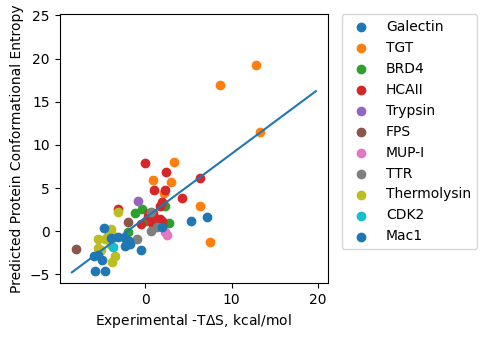

In [5]:
plot_corr( df)

#### Calculate metrics per Protein

Pearson Correlation
	Corr: 0.331
	p_val: 0.167
Linear Regression
	Slope: 0.368
	R-squared: 0.109


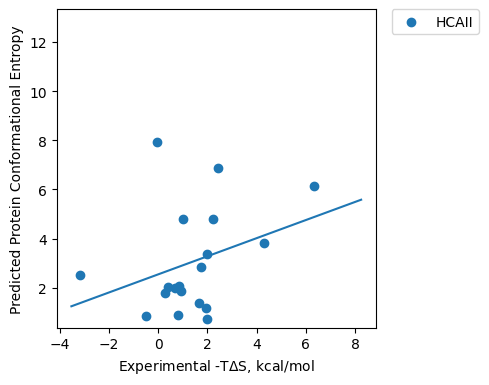

Pearson Correlation
	Corr: 0.599
	p_val: 0.024
Linear Regression
	Slope: 0.424
	R-squared: 0.359


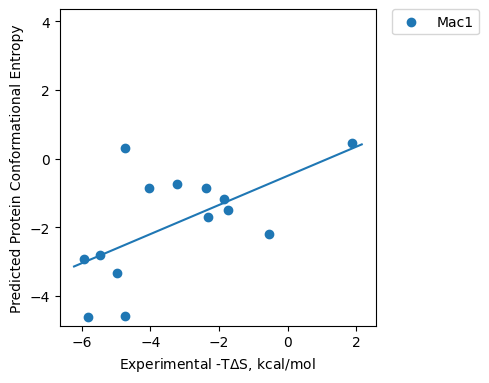

Pearson Correlation
	Corr: 0.3
	p_val: 0.343
Linear Regression
	Slope: 0.598
	R-squared: 0.09


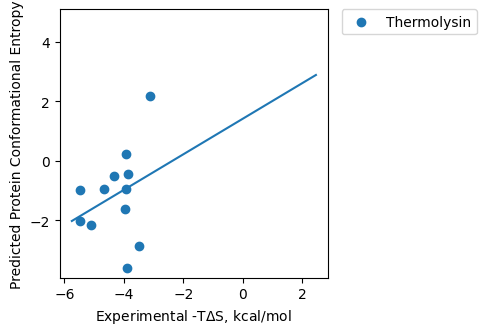

Pearson Correlation
	Corr: 0.588
	p_val: 0.096
Linear Regression
	Slope: 0.857
	R-squared: 0.345


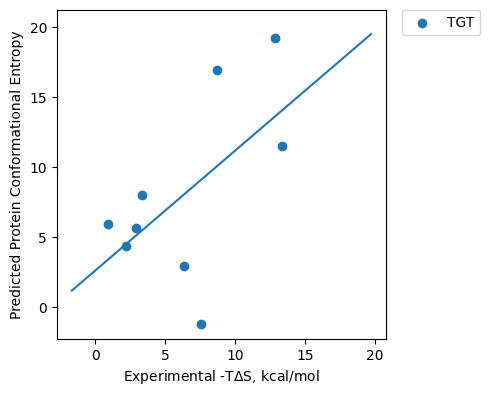

Pearson Correlation
	Corr: 0.313
	p_val: 0.546
Linear Regression
	Slope: 0.192
	R-squared: 0.098


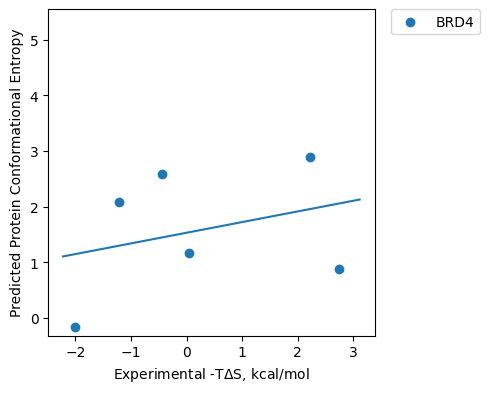

Pearson Correlation
	Corr: 0.554
	p_val: 0.446
Linear Regression
	Slope: 0.708
	R-squared: 0.307


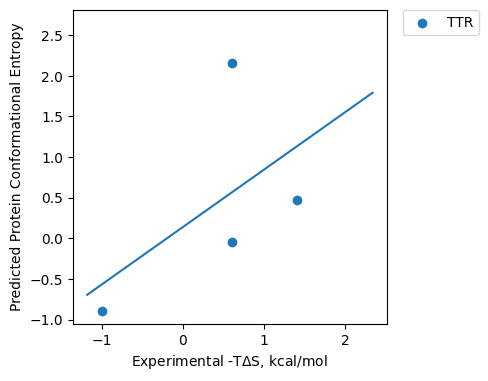

Pearson Correlation
	Corr: -1.0
	p_val: 1.0
Linear Regression
	Slope: -1.389
	R-squared: 1.0


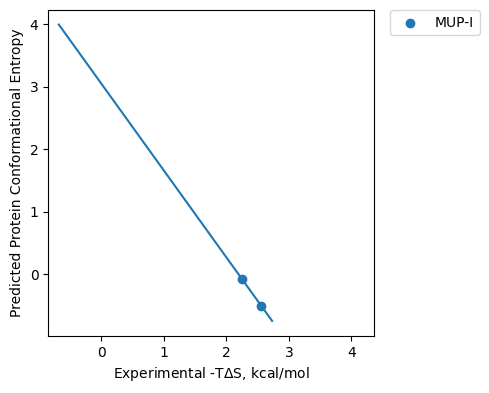

Pearson Correlation
	Corr: 1.0
	p_val: 1.0
Linear Regression
	Slope: 0.526
	R-squared: 1.0


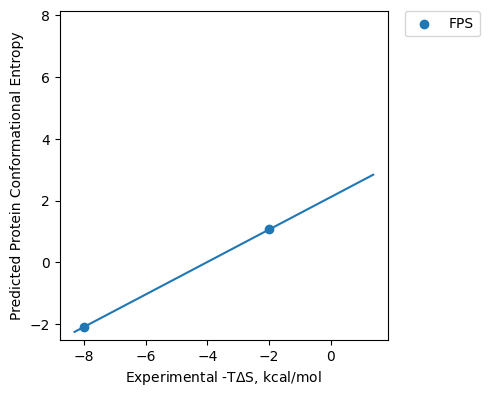

Pearson Correlation
	Corr: 1.0
	p_val: 1.0
Linear Regression
	Slope: 0.247
	R-squared: 1.0


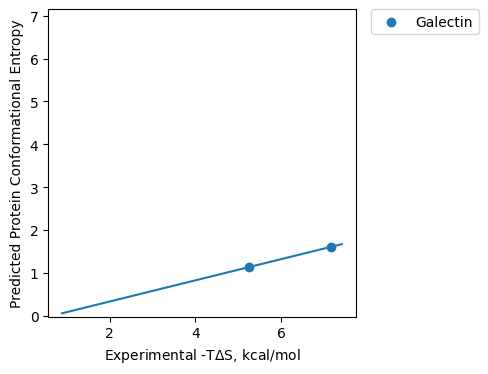

error
error


In [6]:
for prot_name in prot_counts.keys():
    try:
        plot_corr( df[df["Protein"] == prot_name] )
    except:
        print("error")